## Vedant Shirgaonkar
## D114 | D2-2
## EXP3(ML-II)


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and Normalize the images
x_train = x_train.reshape(x_train.shape[0], 28 * 28).astype('float32') / 255
x_test = x_test.reshape(x_test.shape[0], 28 * 28).astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
def create_model():
    model = Sequential([
        Flatten(input_shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [5]:

EPOCHS = 10
BATCH_SIZE = 64 # For Mini-Batch
N_TRAIN = len(x_train)

# List of optimizers to be tested
optimizers_dict = {
    'Gradient Descent': keras.optimizers.SGD(learning_rate=0.01),
    'Stochastic GD': keras.optimizers.SGD(learning_rate=0.01),
    'SGD with Momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Mini-Batch GD': keras.optimizers.SGD(learning_rate=0.01),
    'Adagrad': keras.optimizers.Adagrad(learning_rate=0.01),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'AdaDelta': keras.optimizers.Adadelta(learning_rate=1.0),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

# Dictionary to store the training history of each optimizer
history_dict = {}

for opt_name, optimizer in optimizers_dict.items():
    print(f"===== Training with {opt_name} =====")
    model = create_model()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
  
    if opt_name == 'Gradient Descent':
        current_batch_size = N_TRAIN
    elif opt_name == 'Stochastic GD':
        current_batch_size = 1
    else:
        current_batch_size = BATCH_SIZE
        
    history = model.fit(x_train, y_train,
                        batch_size=current_batch_size,
                        epochs=EPOCHS,
                        validation_data=(x_test, y_test),
                        verbose=1)
    
    history_dict[opt_name] = history

===== Training with Gradient Descent =====


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1452 - loss: 2.3151 - val_accuracy: 0.1538 - val_loss: 2.3072
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.1497 - loss: 2.3095 - val_accuracy: 0.1585 - val_loss: 2.3016
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.1544 - loss: 2.3041 - val_accuracy: 0.1632 - val_loss: 2.2960
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.1588 - loss: 2.2987 - val_accuracy: 0.1686 - val_loss: 2.2906
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - accuracy: 0.1632 - loss: 2.2935 - val_accuracy: 0.1738 - val_loss: 2.2852
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1680 - loss: 2.2883 - val_accuracy: 0.1786 - val_loss: 2.2800
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.1724 - loss: 2.2832 - val_accuracy: 0.1838 - val_loss: 2.2747
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.1770 - loss: 2.2781 - val_accuracy: 0.1887 - val_loss: 2.

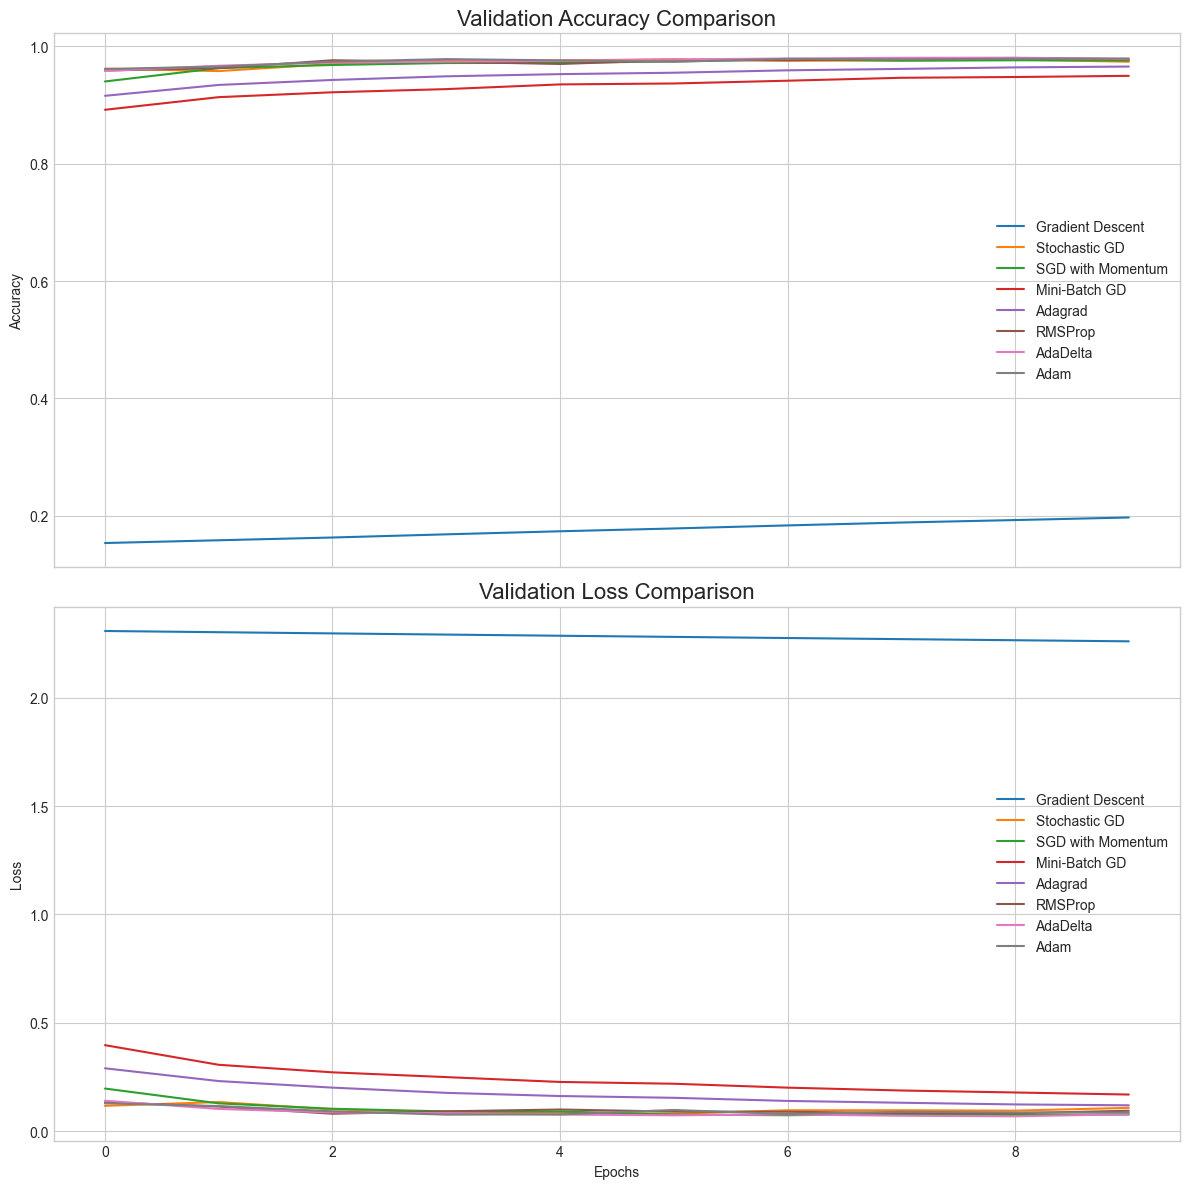

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot Validation Accuracy
for opt_name, history in history_dict.items():
    ax1.plot(history.history['val_accuracy'], label=opt_name)
ax1.set_title('Validation Accuracy Comparison', fontsize=16)
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Validation Loss
for opt_name, history in history_dict.items():
    ax2.plot(history.history['val_loss'], label=opt_name)
ax2.set_title('Validation Loss Comparison', fontsize=16)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.show()

# Advantages and Disadvantages of Each Optimizer

---

### 1. Gradient Descent
**Advantages:**
- Provides a very stable and accurate convergence path because it uses the entire dataset for gradient calculation.

**Disadvantages:**
- Extremely slow and computationally expensive, especially for large datasets.  
- Requires a lot of memory to load the entire dataset.  

---

### 2. Stochastic Gradient Descent (SGD)
**Advantages:**
- Much faster than standard Gradient Descent because it updates parameters for each training example.  
- Low memory requirement.  
- The frequent, noisy updates can help the model escape from local minima.  

**Disadvantages:**
- The convergence path is very noisy and has high variance due to frequent updates.  
- Loses the speed benefit of vectorization since it processes one example at a time.  

---

### 3. SGD with Momentum
**Advantages:**
- Accelerates convergence in the relevant direction and dampens oscillations.  
- Helps overcome high variance and provides a smoother convergence path compared to standard SGD.  

**Disadvantages:**
- Requires an additional hyperparameter (**momentum**) to tune.  

---

### 4. Mini-Batch Gradient Descent
**Advantages:**
- Balances the stability of Gradient Descent and the speed of SGD.  
- Allows for efficient computation through vectorized operations on mini-batches.  

**Disadvantages:**
- Requires tuning the batch size, which is an extra hyperparameter.  

---

### 5. Adagrad (Adaptive Gradient Algorithm)
**Advantages:**
- Uses different, automatically adapted learning rates for each parameter.  
- Eliminates the need to manually tune the learning rate.  
- Well-suited for sparse data.  

**Disadvantages:**
- The learning rate can become infinitesimally small over time, eventually stopping training.  
- AdaDelta was developed to address this issue.  

---

### 6. RMSProp (Root Mean Square Propagation)
**Advantages:**
- Resolves Adagrad’s diminishing learning rate issue using a moving average of squared gradients.  
- Continues to learn effectively even after many epochs.  

**Disadvantages:**
- Still requires manual tuning of the learning rate.  

---

### 7. AdaDelta
**Advantages:**
- Extension of Adagrad that removes the decaying learning rate problem.  
- Does not require a default learning rate to be set.  

**Disadvantages:**
- Can be sensitive to the choice of other hyperparameters and initial conditions.  

---

### 8. Adam (Adaptive Moment Estimation)
**Advantages:**
- Combines benefits of **Momentum** (average of past gradients) and **RMSProp** (average of past squared gradients).  
- Computationally efficient and has low memory requirements.  
- Generally considered the best all-around optimizer for many problems.  

**Disadvantages:**
- Can sometimes fail to converge to the optimal solution in specific cases where other optimizers might succeed.  